# Performing warped GPR 

In [2]:
import pandas as pd
from astropy.time import Time

# Importing data
data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)
data.columns = ["JD", "sind"]
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')
data


C:\Users\Joey\AppData\Local\Temp\ipykernel_54880\299919939.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)


,JD,sind,year
datetime,,,
1966-09-02 08:34:04.799986,2439370.857,0.173873,1966.669013
1966-09-03 08:13:55.199989,2439371.843,0.175041,1966.671713
1966-09-04 07:55:12.000006,2439372.830,0.174457,1966.674415
1966-09-24 08:16:48.000018,2439392.845,0.175236,1966.729213
1966-09-25 07:56:38.399980,2439393.831,0.175918,1966.731912
...,...,...,...
1991-08-26 16:59:31.200009,2448495.208,0.181948,1991.650125
1991-08-28 16:59:31.200009,2448497.208,0.177421,1991.655600
1991-08-29 16:59:31.200009,2448498.208,0.179252,1991.658338


In [4]:
# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.8, valid_split=0.1):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

train_df, valid_df, test_df = split_df(data)
print(train_df.shape, valid_df.shape, test_df.shape)

(1353, 3) (169, 3) (169, 3)


- Now implement the GP over the S-index
- The S-index is strictly positive so must use warping
- Need to extend to include the uncertainties of our datapoints.

In [26]:
import celerite2 
import numpy as np
from celerite2 import terms

# let us use a semi-periodic kernel (exponential times periodic)
kernel = terms.RotationTerm(sigma=1.0, period=11, Q0=0.5, dQ=0.01, f=0.5)
    # period is the dominant period
    # Q0 higher means sharper, more coherent oscillation
    # dQ is a secondary peak at P/2 set low to supress it
    # f near 0 single peak at P; near 1 → strong harmonic at P/2

# now the GP
gp =  celerite2.GaussianProcess(kernel, mean = 0.175) # HOW DO WE CHOOSE THIS MEAN VALUE
gp.compute(train_df['year'], yerr = 1e-3) # only needs the timestamps because this does the matrix factorisation
    # it only needs to know the exact values later




In [27]:
# Now fit the GPR with optimize
from scipy.optimize import minimize

def get_params(kernel):
    return np.log([kernel.sigma, kernel.period, kernel.Q0, kernel.dQ, kernel.f])

def set_params(kernel, log_params):
    vals = np.exp(log_params)
    kernel.sigma = vals[0]
    kernel.period = vals[1]
    kernel.Q0 = vals[2]
    kernel.dQ = vals[3]
    kernel.f = vals[4]

def NLL(log_params, gp, y):
    set_params(gp.kernel, log_params) # try these parameter values
    try:
        gp.recompute(quiet=True) #  recompute the matrix factorisations
        return -gp.log_likelihood(y)
    except: # if some params make the cov go non PSD then we error
        return 1e10
    
initial_guess = get_params(gp.kernel) # just the values from when we set the kernel

gp_res = minimize( # The optimisation result
    NLL,
    initial_guess,
    args=(gp,train_df['sind']),
    method="L-BFGS-B",
    )

set_params(gp.kernel, gp_res.x)  # apply the best-fit parameters
gp.recompute()         

print(gp_res.success, gp_res.message)

True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


In [28]:
# now predict
t_pred = valid_df['year']
mu, cov = gp.predict(train_df['sind'], t = t_pred, return_var = True)
sigma = np.sqrt(cov)

In [17]:
import matplotlib.pyplot as plt

def plot_predictions(trainingset, validset, results):
    fig,ax = plt.subplots(figsize = (20,5))
    ax.plot(trainingset['year'], trainingset['sind'], color = 'blue', label = 'Training')
    ax.plot(validset['year'], validset['sind'], color = 'orange', label = 'Actual')
    results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(results_time, results['forecast'], color = 'green', label = 'Predictions')
    # ax.fill_between(results_time, results['lower'], results['upper'], color = 'green', alpha = 0.2, label = 'Uncertainties')
    plt.legend()
    plt.show()

In [18]:
results = pd.DataFrame({
    'forecast' : mu,
    'lower'    : mu - sigma,
    'upper'    : mu + sigma,
}, index=valid_df.index)

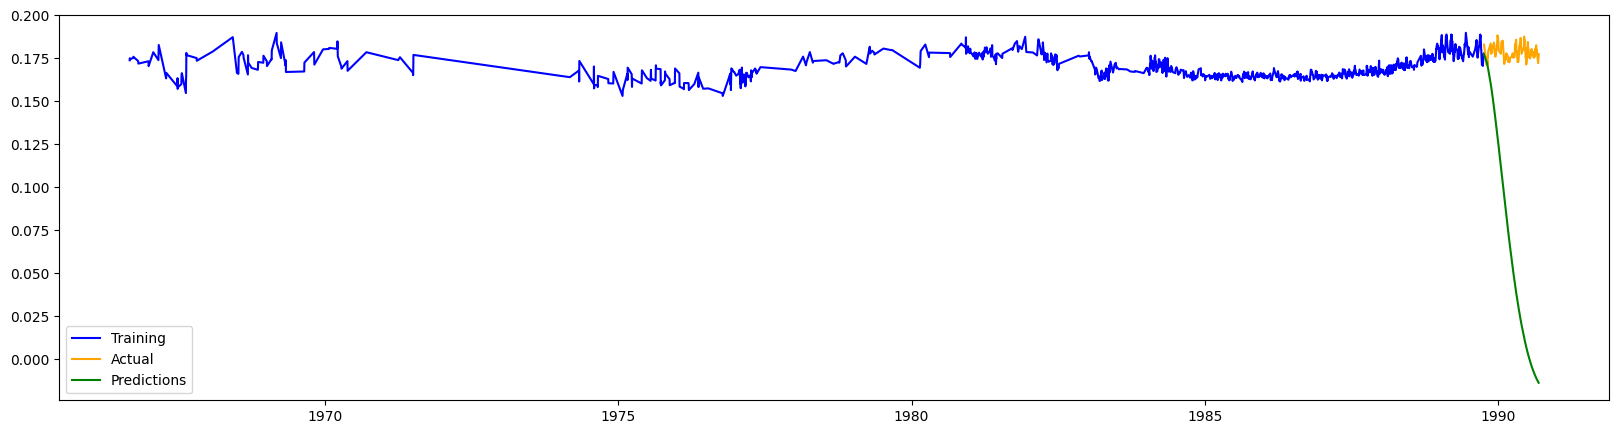

In [29]:
plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results
                 )